In [1]:
from typing import Iterator

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets.packaged_modules.webdataset.webdataset import torch_loads
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from torch.nn import Parameter
from torch.utils.data import TensorDataset, DataLoader

from higashi.Higashi_vis.main import cell_num
from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

In [3]:
from examples.case_studies.sc_GEM_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [3]:
len(labels)

224

In [4]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(data == 0, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [5]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 59
After remove all nan 34
After remove all zeros 33
Input #cols 59
After remove all nan 27
After remove all zeros 27


Text(0.5, 1.0, 'methylation_data_clean')

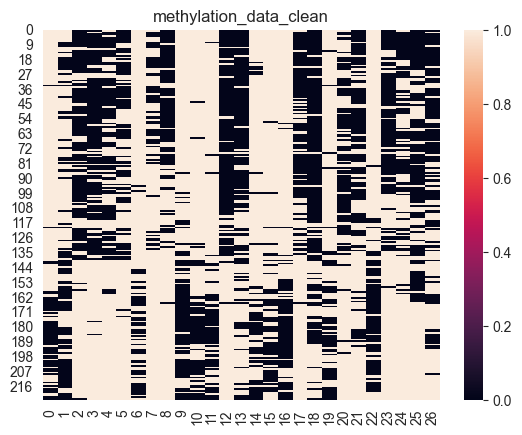

In [6]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

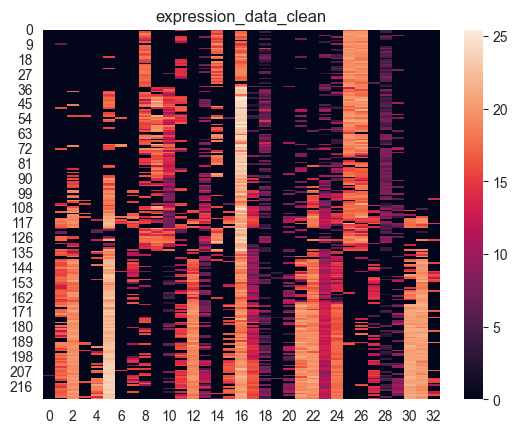

In [7]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [8]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [9]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [10]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3023, 3), (3023,), (3782, 3), (3782,))

In [11]:
expression_edges.max(0), methylation_edges.max(0)

(array([223,  32,   0]), array([223,  59,   1]))

In [12]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [13]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [14]:
edges.shape, weights.shape

((6805, 3), (6805,))

In [15]:
np.any(weights == 0)

False

In [16]:
save_edges_and_weights('./data/sc_GEM', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [17]:
train_data = np.load('./data/sc_GEM/train_data.npz', allow_pickle=True)
test_data = np.load('./data/sc_GEM/test_data.npz', allow_pickle=True)

In [18]:
train_data['nums_type']

array([224,  60,   2])

In [ ]:
!python3 hgnn/main_torch_zinb.py --data sc_GEM --feature adj --loss zinb --iter 50

1.0 -0.5
model_no_randomwalk
Use train_weight (5444,)
Node type num [224  60   2]
embeddings_initial [False, False, False]
[23.630938  1.        1.       ... 20.532925 16.36166   1.      ] 1.0 25.435984
walk type 
adding pad idx
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
1.0 -0.5
dict_size 5444 6805
train data amount 5444
64
tensor([  0, 224, 284, 286])
w.shape (224, 62)
(224, 62)
w.shape (60, 226)
(60, 226)
w.shape (2, 284)
(2, 284)
self.input_size [62, 226, 284]
inp 62 out 64 weight.shape torch.Size([64, 62])
fan_in 62 7.874007874011811
inp 226 out 64 weight.shape torch.Size([64, 226])
fan_in 226 15.033296378372908
inp 284 out 64 weight.shape torch.Size([64, 284])
fan_in 284 16.852299546352718
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 MultipleEmbedding-1           [[-1, 64], [-1]] 

In [23]:
!mkdir -p ./embeddings/hgnn/sc_GEM

In [24]:
!mv ./*.npy ./embeddings/hgnn/sc_GEM


zsh:1: no matches found: ./*.npy


## Analysis

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from hgnn.phasing import *

In [2]:
cell_embeddings = np.load('./embeddings/sc_GEM/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/sc_GEM/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/sc_GEM/mymodel_2.npy', allow_pickle=True)


In [21]:
cell_embeddings.shape

(224, 64)

{'NMI': 0.5164129296289204,
 'ARI': 0.3870812308387961,
 'FMI': 0.47049858159114266}

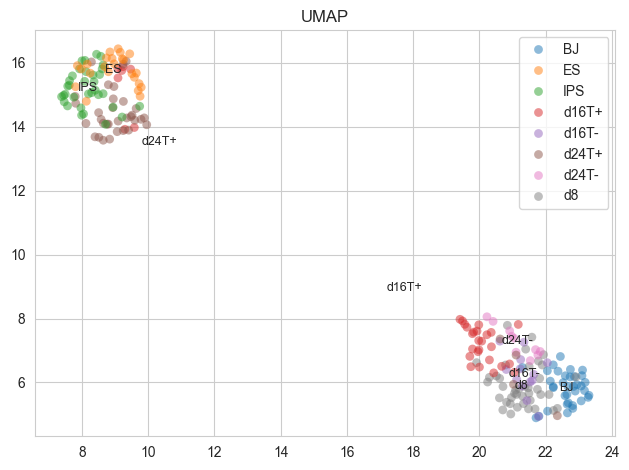

In [22]:
umap_visualize(cell_embeddings, labels)

## Phasing

In [6]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
O = torch.tensor(omic_embeddings, dtype=torch.float)
X = torch.tensor(np.concatenate([expression_data_clean, methylation_data_clean], axis=1), dtype=torch.float)

In [9]:
L = build_laplacian(C)

torch.trace(X.T @ L @ X)

NameError: name 'np' is not defined

<Axes: >

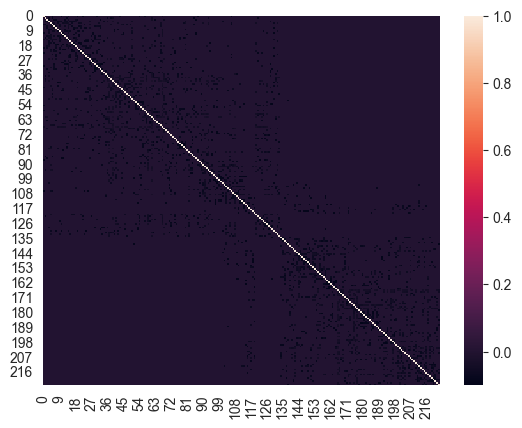

In [363]:
sns.heatmap(L)

In [364]:
np.min(np.linalg.eigvalsh(L))

8.333933e-10

In [369]:
epochs = 5000
embed_dim = C.shape[1]
# 超参，按需要调
alpha = 0.001
perplexity = k = 3
lr = 1e-3
omics_offset = expression_data_clean.shape[1]
num_cells = C.shape[0]
num_genes = G.shape[0]
embed_dim, omics_offset

(64, 33)

Epoch   0  total=100.174  rec=82.057  reg=18117.529
Epoch 100  total=40.025  rec=26.825  reg=13199.275
Epoch 200  total=34.377  rec=22.443  reg=11933.772
Epoch 300  total=31.992  rec=20.556  reg=11436.227
Epoch 400  total=30.570  rec=19.356  reg=11213.456
Epoch 500  total=29.606  rec=18.513  reg=11093.287
Epoch 600  total=28.906  rec=17.891  reg=11015.055
Epoch 700  total=28.371  rec=17.415  reg=10956.182
Epoch 800  total=27.946  rec=17.038  reg=10907.926
Epoch 900  total=27.602  rec=16.734  reg=10867.963
Epoch 1000  total=27.314  rec=16.479  reg=10835.551
Epoch 1100  total=27.068  rec=16.258  reg=10809.164
Epoch 1200  total=26.852  rec=16.063  reg=10788.562
Epoch 1300  total=26.660  rec=15.888  reg=10772.640
Epoch 1400  total=26.487  rec=15.727  reg=10760.629
Epoch 1500  total=26.330  rec=15.578  reg=10751.950
Epoch 1600  total=26.185  rec=15.439  reg=10745.907
Epoch 1700  total=26.051  rec=15.308  reg=10742.387
Epoch 1800  total=25.926  rec=15.185  reg=10741.076
Epoch 1900  total=25.

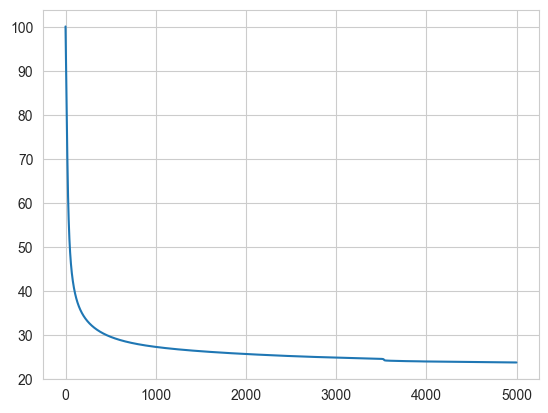

In [370]:
model, histories = train_phasing_model(
    embed_dim=embed_dim,
    omics_offset=omics_offset,
    epochs=epochs,
    lr=lr,
    k=k,
    alpha=alpha,
    C=C, G=G, O=O, X=X,
)

In [371]:
Xp0, Xp1, Xm0, Xm1 = model.predict(G, C, O)

Text(0.5, 1.0, 'X1')

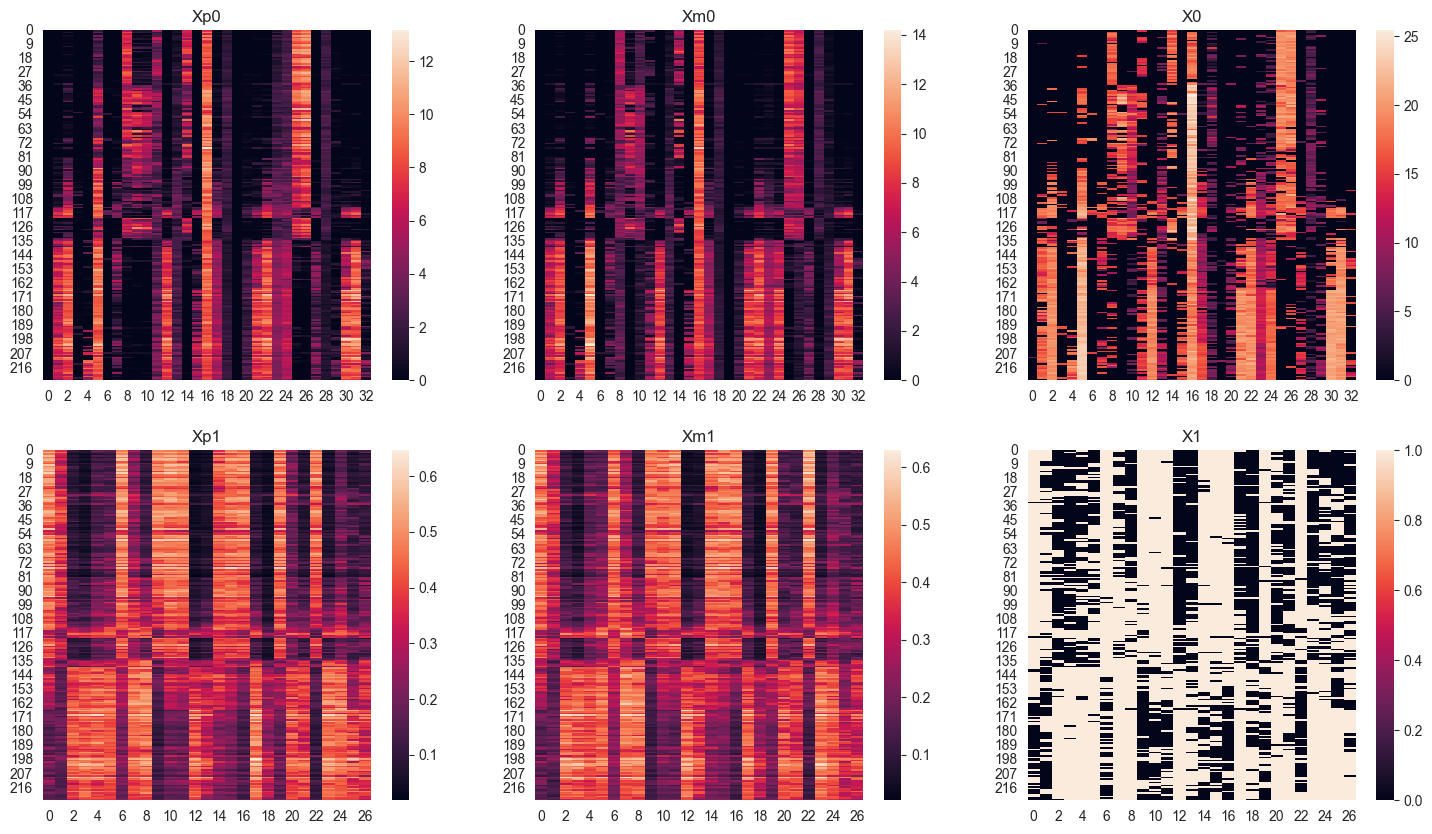

In [372]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp0,ax=ax)
plt.title('Xp0')
ax = plt.subplot(232)
sns.heatmap(Xm0,ax=ax)
plt.title('Xm0')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X0')
ax = plt.subplot(234)
sns.heatmap(Xp1,ax=ax)
plt.title('Xp1')
ax = plt.subplot(235)
sns.heatmap(Xm1,ax=ax)
plt.title('Xm1')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X1')

{'NMI': 0.47673373013051196,
 'ARI': 0.3259323996201474,
 'FMI': 0.42022714430462277}

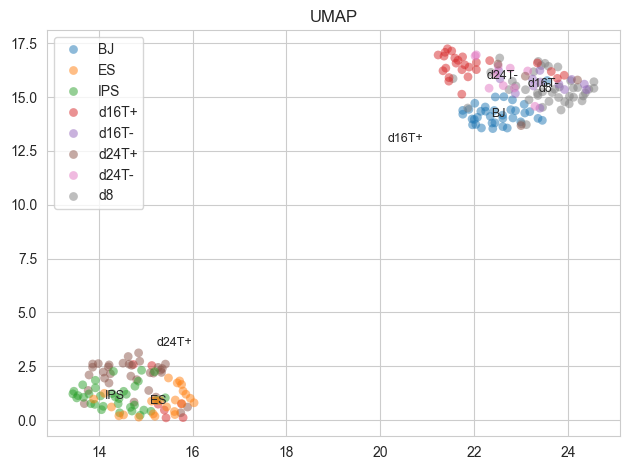

In [373]:
umap_visualize(C, labels)

{'NMI': 0.569576390500928, 'ARI': 0.42587925870648, 'FMI': 0.5039960040508557}

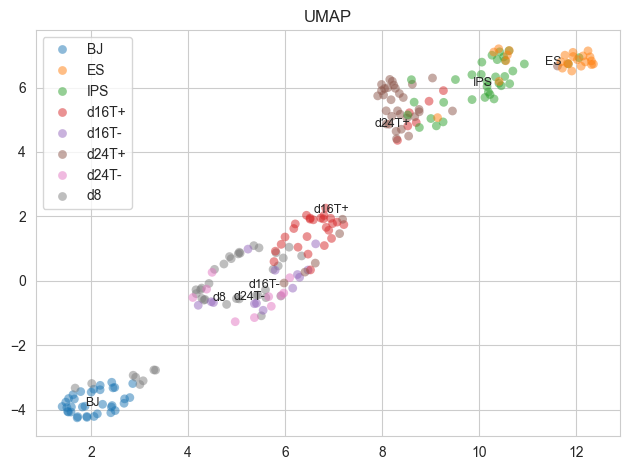

In [374]:
umap_visualize(Xp0, labels)


{'NMI': 0.5934407633769817,
 'ARI': 0.41948259065323457,
 'FMI': 0.498943127010491}

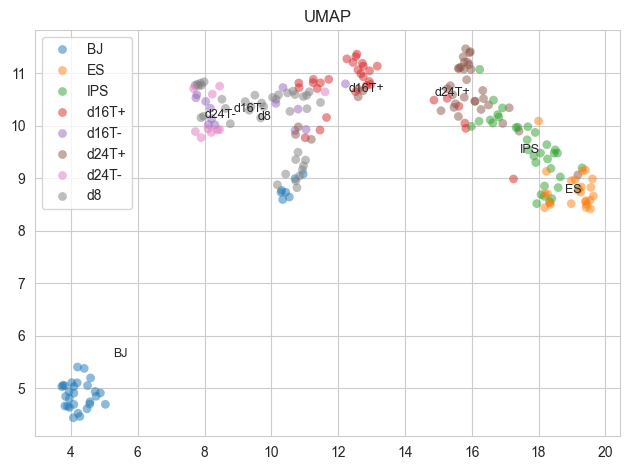

In [375]:
umap_visualize(Xm0, labels)


{'NMI': 0.4633000696731224,
 'ARI': 0.3148901703768412,
 'FMI': 0.4088927534055122}

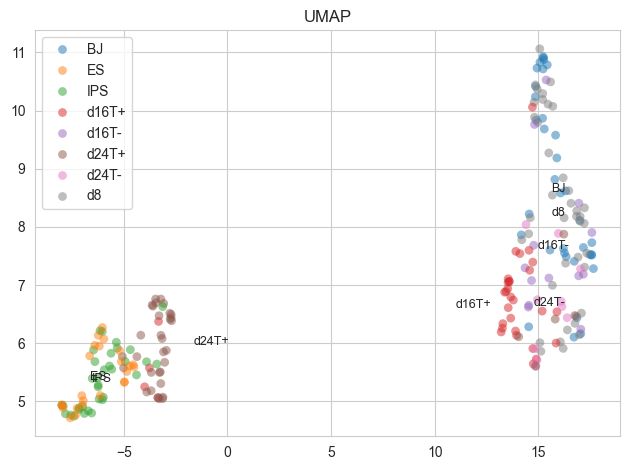

In [376]:
umap_visualize(Xp1, labels)


{'NMI': 0.4560047368171257,
 'ARI': 0.270319203379424,
 'FMI': 0.37501691265994386}

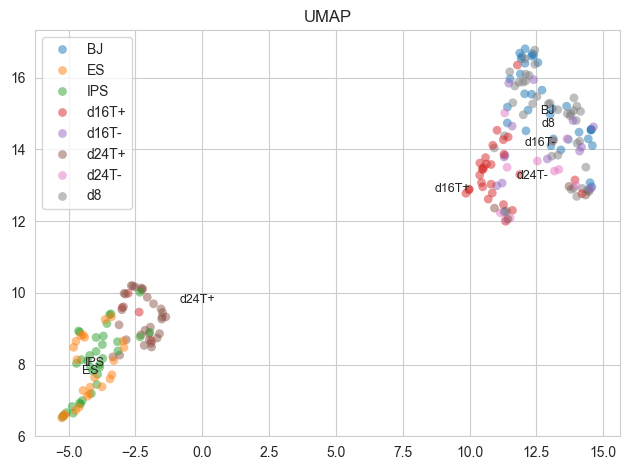

In [377]:
umap_visualize(Xm1, labels)
